In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Number of CUDA devices:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Current CUDA device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("No GPU (CUDA) available. Running on CPU.")

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Number of CUDA devices: 1
Current CUDA device: 0
Device name: NVIDIA RTX A4000


In [2]:
## read data
import numpy as np

results = np.load('river1.npy', allow_pickle=True).item()

centerline_points = results['centerline']
smooth_cross_sections = results['cross_sections']
velocity_distributions = results['velocity_distributions']

print("Number of centerline points:", len(centerline_points))
print("Number of cross-sections:", len(smooth_cross_sections))
print("Number of velocity distribution data points:", len(velocity_distributions))

# Example: Accessing the velocity distribution of the first cross-section
first_section_velocity = velocity_distributions[0]['velocities']
B =  velocity_distributions[0]['Bottom width']
H_of_water =  velocity_distributions[0]['Hofwater']
print("Width of the first cross-section:", B)
print("Velocity distribution of the first cross-section:", first_section_velocity)
print("Water depth distribution of the first cross-section:", H_of_water)


Number of centerline points: 875
Number of cross-sections: 35
Number of velocity distribution data points: 35
Width of the first cross-section: 6.929646455628166
Velocity distribution of the first cross-section: [0.         0.22578669 0.28742988 0.33802343 0.36965837 0.40014972
 0.41340492 0.42412645 0.43366614 0.44224868 0.45008912 0.45632534
 0.46249832 0.46663226 0.46849947 0.47003299 0.47019815 0.47031719
 0.47270433 0.47479884 0.4751345  0.48109815 0.4871966  0.49039076
 0.49196444 0.49369735 0.49680541 0.50020736 0.50210022 0.50265401
 0.50158126 0.49909755 0.49542544 0.49095615 0.48553185 0.4808981
 0.47622306 0.47184253 0.46929278 0.46589575 0.46188739 0.45598164
 0.44452563 0.42246436 0.39761684 0.34250601 0.27816238 0.21445984
 0.        ]
Water depth distribution of the first cross-section: [0.         0.12502523 0.23218097 0.26828265 0.29958216 0.32505532
 0.33833647 0.3450311  0.35008409 0.35619533 0.35918978 0.36569374
 0.37212753 0.3758488  0.37568209 0.37423575 0.370832

In [3]:
import torch
from scipy.interpolate import interp1d

def load_array(data_arrays, batch_size, is_train=False):  #@save

    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

def fun_calDiff(data, y, num_points=50):
    if len(data) != len(y):
        raise ValueError("data and y must have the same length")
    
    indices = np.linspace(0, len(data) - 1, num_points)

    interp_data = interp1d(np.arange(len(data)), data, kind='linear', fill_value="extrapolate")
    interp_y = interp1d(np.arange(len(y)), y, kind='linear', fill_value="extrapolate")
    data = interp_data(indices)
    y = interp_y(indices)

    U_avi, U_diff, Y_diff = [], [], []

    for i in range(len(data) - 1):
        if y[i + 1] == y[i]:
            raise ValueError("y[i+1] - y[i] is zero, cannot divide by zero")
            # return 100
        U_avi.append((data[i + 1] + data[i]) / 2)
        U_diff.append(abs((data[i + 1] - data[i])) / abs(y[i + 1] - y[i]))
        Y_diff.append(abs(y[i + 1] - y[i]))

    return U_avi, U_diff, Y_diff

def PredSplitData(data0,num_points=50,alpha=0.8):
    B0 = data0[int(len(data0)-1)]
    dsize = int((len(data0)-1)/2.0)
    Ux0 = data0[0:dsize] / alpha
    Y = data0[dsize:2*dsize]
    # inValueU = Ux0

## Data Grade Enhance————
    max_index = np.argmax(Ux0)
    Bleft = B0* (max_index + 1)/len(Ux0)
    Bright = B0-Bleft
    Uint = Ux0[:max_index + 1]
    Yint = Y[:max_index + 1]
    U_avi,U_diff,Y_diff = fun_calDiff(Uint,Yint)
##——————————————————————————————————————

    pin_np1 = np.array(U_avi).reshape(1,-1)
    pin_np2 = np.array(U_diff).reshape(1,-1)
    pin_np3 = np.array(Y_diff).reshape(1,-1)
    pin_npleft = np.vstack((pin_np1, pin_np2, pin_np3))

    Uint = Ux0[max_index:]
    Uint = Uint[::-1]
    Yint = Y[max_index:]
    Yint = Yint[::-1]
    U_avi,U_diff,Y_diff = fun_calDiff(Uint,Yint,num_points=num_points)
    pin_np1 = np.array(U_avi).reshape(1,-1)
    pin_np2 = np.array(U_diff).reshape(1,-1)
    pin_np3 = np.array(Y_diff).reshape(1,-1)
    pin_npright = np.vstack((pin_np1, pin_np2, pin_np3))

    return pin_npleft, pin_npright,Bleft,Bright

def genFeaturesAndB(data_set,num_points=50,alpha=0.8):
    featurel,featurer,Bl,Br=[],[],[],[]
    for data0 in data_set:
        pin_npleft, pin_npright,Bleft,Bright =PredSplitData(data0,num_points=num_points,alpha=alpha)
        featurel.append(pin_npleft)
        Bl.append(Bleft)
        featurer.append(pin_npright)
        Br.append(Bright)
    featuresl =  torch.from_numpy(np.array(featurel))
    featuresr =  torch.from_numpy(np.array(featurer))
    BL = torch.from_numpy(np.array(Bl))
    BR = torch.from_numpy(np.array(Br))
    return featuresl, featuresr, BL, BR

def realprediction(data_iter,net,cuda=False,l=0,r=0):
    Q_pred,H_pred,V_pred=[],[],[]
    if l==1:
        for featuresl, featuresr, BL, BR in data_iter:
            pin_np= featuresl
            pin = torch.from_numpy(np.float32(pin_np))
            pin.requires_grad = False
            if cuda:
                pred = net(pin.cuda())
            else:
                pred = net(pin.cpu())  
            UH_preds = pred.detach().cpu().numpy()
            for UH_pred,b in zip(UH_preds,BL):
                Q0_pred = UH_pred[0]*UH_pred[1]*b
                Q_pred.append(Q0_pred) 
                V0_pred = UH_pred[0]
                V_pred.append(V0_pred)
                H0_pred = UH_pred[1]
                H_pred.append(H0_pred)
    if r==1:        
        for featuresl, featuresr, BL, BR in data_iter:
            pin_np= featuresr
            pin = torch.from_numpy(np.float32(pin_np))
            pin.requires_grad = False
            if cuda:
                pred = net(pin.cuda())
            else:
                pred = net(pin.cpu())  
            UH_preds = pred.detach().cpu().numpy()
            for UH_pred,b in zip(UH_preds,BR):
                Q0_pred = UH_pred[0]*UH_pred[1]*b
                Q_pred.append(Q0_pred) 
                V0_pred = UH_pred[0]
                V_pred.append(V0_pred)
                H0_pred = UH_pred[1]
                H_pred.append(H0_pred)
    if l+r ==2:
        print('error,l&r==!2')
    if l+r==0:
        print('not defiend l&r')

    return Q_pred, V_pred, H_pred

In [4]:
import sys
from pathlib import Path
current_dir = Path().resolve()  
ModelBase_path = current_dir.parent / 'Model_Base'
sys.path.append(str(ModelBase_path))
import os
import random
from Model import ResNetGELU
import numpy as np
import matplotlib.pyplot as plt

def plotrealriver(Q_pred,Qx,V_pred,Vx,H_pred,Hx):
    # Create line plots
    plt.figure(figsize=(15, 10))

    # Plot for Q values
    plt.subplot(3, 1, 1)  # 3 rows, 1 column, 1st subplot
    plt.plot(Q_pred, label='Predicted Q', color='blue')
    plt.plot(Qx, label='Actual Q', color='orange')
    plt.title('Comparison of Q Values')
    plt.xlabel('Sample Index')
    plt.ylabel('Q Value')
    plt.legend()
    plt.grid()

    # Plot for V values
    plt.subplot(3, 1, 2)  # 3 rows, 1 column, 2nd subplot
    plt.plot(V_pred, label='Predicted V', color='blue')
    plt.plot(Vx, label='Actual V', color='orange')
    plt.title('Comparison of V Values')
    plt.xlabel('Sample Index')
    plt.ylabel('V Value')
    plt.legend()
    plt.grid()

    # Plot for H values
    plt.subplot(3, 1, 3)  # 3 rows, 1 column, 3rd subplot
    plt.plot(H_pred, label='Predicted H', color='blue')
    plt.plot(Hx, label='Actual H', color='orange')
    plt.title('Comparison of H Values')
    plt.xlabel('Sample Index')
    plt.ylabel('H Value')
    plt.legend()
    plt.grid()

    # Adjust layout
    plt.tight_layout()
    plt.show()


In [5]:
def plotrealriver_alpha(Q_pred, Q_pred_alpha, Qx, V_pred, V_pred_alpha, Vx, H_pred, H_pred_alpha, Hx):

    from sklearn.metrics import mean_squared_error, r2_score
    metrics = {}
    for name, pred, true in [('Q', Q_pred, Qx), ('V', V_pred, Vx), ('H', H_pred, Hx)]:
        mse = mean_squared_error(true, pred)
        r2 = r2_score(true, pred)
        metrics[name] = {'MSE': mse, 'R²': r2}

    plt.rcParams.update({'font.size': 18})
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.rm'] = 'Times New Roman'
    plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
    plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
    
    fig = plt.figure(figsize=(8, 8))
    plt.subplots_adjust(top=0.85)
    
    ax2 = plt.subplot(2, 1, 1)
    
    ax2.plot(V_pred, label=r'Predicted ($\alpha=1$)', color='blue', linewidth=1.5, linestyle='--')
    
    ax2.plot(V_pred_alpha, label=r'Predicted ($\alpha=0.8$)', color='blue', linewidth=2)
    ax2.plot(Vx, label='Measured (Masafu et al., 2022)', color='red', linewidth=2)

    # ax2.set_title('Cross-sectional Average Velocity ($V$)', fontsize=20, pad=15)
    # ax2.set_xlabel('Cross sections', fontsize=20)
    ax2.set_ylabel('$V$ (m/s)', fontsize=20)
    
    handles, labels = ax2.get_legend_handles_labels()
    
    ordered_handles = [handles[1], handles[0], handles[2]]
    ordered_labels = [labels[1], labels[0], labels[2]]
    
    legend1 = ax2.legend([ordered_handles[0], ordered_handles[1]], 
                        [ordered_labels[0], ordered_labels[1]], 
                        loc='upper left', bbox_to_anchor=(0.001, 1.02), 
                        ncol=2, frameon=False, fontsize=18)
    ax2.add_artist(legend1)
    
    legend2 = ax2.legend([ordered_handles[2]], [ordered_labels[2]], 
                        loc='upper left', bbox_to_anchor=(0.001, 0.87), 
                        ncol=1, frameon=False, fontsize=18)
    
    y_min = min(min(V_pred), min(Vx), min(V_pred_alpha))
    y_max = max(max(V_pred), max(Vx), max(V_pred_alpha))
    ax2.set_ylim(y_min - 0.12, y_max + 0.3)  

    ax3 = plt.subplot(2, 1, 2)
    ax3.plot(H_pred, label=r'Predicted ($\alpha=1$)', color='blue', linewidth=1.5, linestyle='--')
    ax3.plot(H_pred_alpha, label=r'Predicted ($\alpha=0.8$)', color='blue', linewidth=2)
    ax3.plot(Hx, label='Measured (Masafu et al., 2022)', color='red', linewidth=2)
    ax3.set_xlabel('Cross Sections', fontsize=20)
    ax3.set_ylabel('$H$ (m)', fontsize=20)
    
    handles, labels = ax3.get_legend_handles_labels()
    ordered_handles = [handles[1], handles[0], handles[2]]
    ordered_labels = [labels[1], labels[0], labels[2]]
    
    legend3 = ax3.legend([ordered_handles[0], ordered_handles[1]], 
                        [ordered_labels[0], ordered_labels[1]], 
                        loc='upper left', bbox_to_anchor=(0.001, 1.02), 
                        ncol=2, frameon=False, fontsize=18)
    ax3.add_artist(legend3)
    
    legend4 = ax3.legend([ordered_handles[2]], [ordered_labels[2]], 
                        loc='upper left', bbox_to_anchor=(0.001, 0.87), 
                        ncol=1, frameon=False, fontsize=18)
    
    y_min = min(min(H_pred), min(Hx), min(H_pred_alpha))
    y_max = max(max(H_pred), max(Hx), max(H_pred_alpha))
    ax3.set_ylim(y_min - 0.12 , y_max + 0.35)  

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, top=0.85)
    plt.show()
    
    return metrics


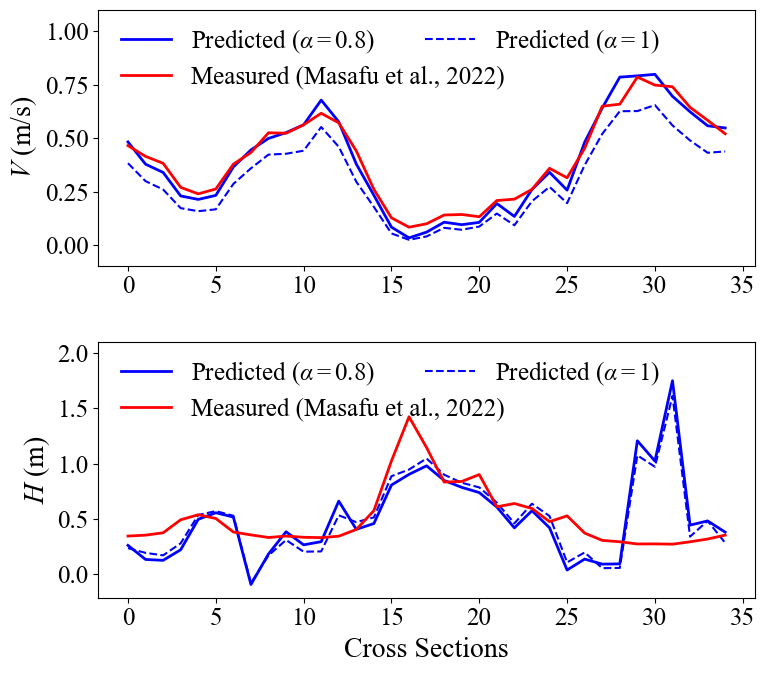

{'Q': {'MSE': 1.0217545479095864, 'R²': -71899589640192.0},
 'V': {'MSE': 0.01033439568979824, 'R²': 0.7430989341604521},
 'H': {'MSE': 0.11648547222886031, 'R²': -0.5764151834792111}}

In [6]:
data_set=np.float32(np.loadtxt('realriver1.dat',unpack=True))
results = np.load('river1.npy', allow_pickle=True).item()
featurel,featurer,bl,br = genFeaturesAndB(data_set,num_points=50,alpha=1)
bl = bl.cpu().detach().numpy().tolist()
br = br.cpu().detach().numpy().tolist()
data_iter = load_array(genFeaturesAndB(data_set,num_points=50,alpha=1),batch_size=1,is_train=False)
a=len(featurel[0,0,:])
b=len(featurel[0])
net=ResNetGELU(in_channels=b)
trainName="ResNetdatapro3S_Minus07_use"
NAME=trainName
net = torch.load(NAME,weights_only=False)
net.eval()
net.cuda()
Q_predl, V_predl, H_predl = realprediction(data_iter,net,cuda=True,l=1)
Q_predr, V_predr, H_predr = realprediction(data_iter,net,cuda=True,r=1)
# Q_pred = Q_predl+Q_predr
Q_pred,V_pred,H_pred=[],[],[]
for i in range(len(Q_predl)):
    Q_pred.append(Q_predl[i]+Q_predr[i])
    V_pred.append((bl[i]*V_predl[i]+br[i]*V_predr[i])/(br[i]+bl[i]))
    H_pred.append((bl[i]*H_predl[i]+br[i]*H_predr[i])/(br[i]+bl[i]))

## by alpha 
data_iter = load_array(genFeaturesAndB(data_set,num_points=50,alpha=0.8),batch_size=1,is_train=False)
a=len(featurel[0,0,:])
b=len(featurel[0])
net=ResNetGELU(in_channels=b)
trainName="ResNetdatapro3S_Minus07_use"
NAME=trainName
net = torch.load(NAME,weights_only=False)
net.eval()
net.cuda()
Q_predl, V_predl, H_predl = realprediction(data_iter,net,cuda=True,l=1)
Q_predr, V_predr, H_predr = realprediction(data_iter,net,cuda=True,r=1)
# Q_pred = Q_predl+Q_predr
Q_pred_alpha,V_pred_alpha,H_pred_alpha=[],[],[]
for i in range(len(Q_predl)):
    Q_pred_alpha.append(Q_predl[i]+Q_predr[i])
    V_pred_alpha.append((bl[i]*V_predl[i]+br[i]*V_predr[i])/(br[i]+bl[i]))
    H_pred_alpha.append((bl[i]*H_predl[i]+br[i]*H_predr[i])/(br[i]+bl[i]))


# results = np.load('river4.npy', allow_pickle=True).item()
velocity_distributions = results['velocity_distributions']
Hx, Bxx = [],[]
for i, data in enumerate(velocity_distributions):
    Hx.append(data['H'])
    Bxx.append(data['Bottom width'])
Bx = data_set.T[int(len(data_set.T)-1)]
Qx = np.full_like(Bx, 1.1)
Vx = Qx / (Bx * Hx)
plotrealriver_alpha(Q_pred, Q_pred_alpha, Qx, V_pred, V_pred_alpha, Vx, H_pred, H_pred_alpha, Hx)

[1, 3, 4, 5, 13, 14, 15, 16, 17, 18, 19, 20, 21, 27, 28, 34]


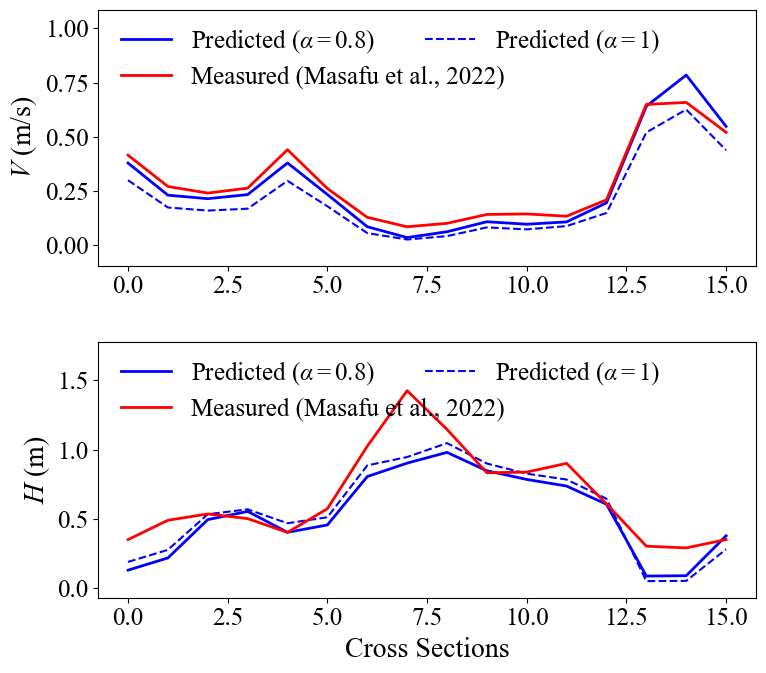

{'Q': {'MSE': 0.3549663112961493, 'R²': 0.0},
 'V': {'MSE': 0.007297840215507736, 'R²': 0.7832201965087868},
 'H': {'MSE': 0.03047295617107549, 'R²': 0.7090288288967057}}

In [7]:
idx ,idx_error= [],[]
for i,(hl,hr) in enumerate(zip(H_predl,H_predr)):
    if np.abs(hl - hr) < abs(min(hl, hr)) and hl > 0 and hr > 0:
        idx.append(i)
    else :
        idx_error.append(i)
print (idx)
Qp = [Q_pred[i] for i in idx]
Qp_alpha = [Q_pred_alpha[i] for i in idx]
Qr = [Qx[i] for i in idx]
Vp = [V_pred[i] for i in idx]
Vp_alpha = [V_pred_alpha[i] for i in idx]
Vr = [Vx[i] for i in idx]
Hp = [H_pred[i] for i in idx]
Hp_alpha = [H_pred_alpha[i] for i in idx]
Hr = [Hx[i] for i in idx]
plotrealriver_alpha(Qp, Qp_alpha, Qr, Vp, Vp_alpha, Vr, Hp, Hp_alpha, Hr)

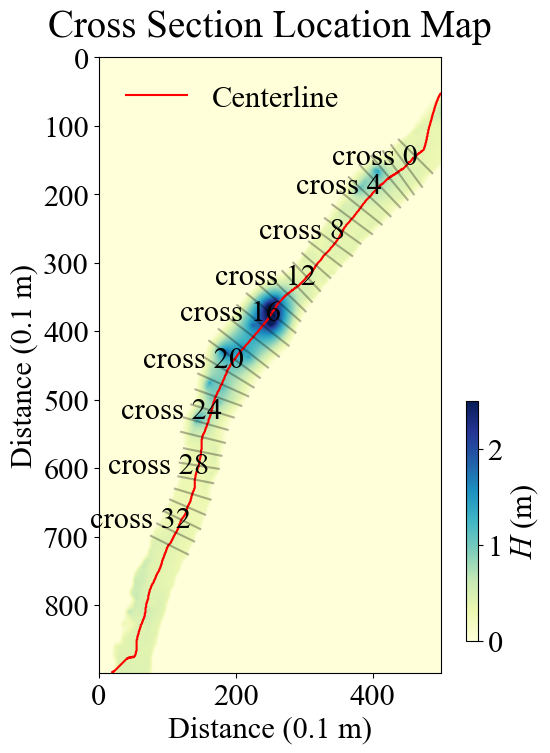

In [8]:
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import sys
from pathlib import Path
current_dir = Path().resolve() 
RiverData_path = current_dir.parent.parent / 'Data/river'
results = np.load('river1.npy', allow_pickle=True).item()
boundary_points = results['boundary_points']
dem_dataH = tiff.imread(RiverData_path / 'Hx.tif')
dem_dataH = np.nan_to_num(dem_dataH, nan=0)
dem_dataH = np.where(dem_dataH < 0, 0, dem_dataH)
H1 = dem_dataH[3300:4200,1400:1900]

fig = plt.figure(figsize=(15, 8),dpi=100)
plt.rcParams['font.family'] = 'Times New Roman'
im = plt.imshow(H1, cmap='YlGnBu', vmin=0, vmax=2.5) 
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=22)
cbar.set_label('$H$ (m)', fontsize=22)
cbar.ax.set_position([0.85, 0.15, 0.02, 0.3]) 
plt.plot(centerline_points[:,0], centerline_points[:,1], 'r-', linewidth=1.5, label='Centerline')

for i, (left, right) in enumerate(boundary_points):
    plt.plot([left[0], right[0]], [left[1], right[1]], 'black', alpha=0.3)
    # Label every 5th cross-section
    if i % 4 == 0:
        mid_x = ((left[0] + right[0]) / 2)-60
        mid_y = (left[1] + right[1]) / 2
        plt.text(mid_x, mid_y, f'cross {i}', color='black', fontsize=22, 
                fontweight='normal', ha='center', va='center')

plt.title('Cross Section Location Map', fontsize=28, pad=15)
plt.legend(fontsize=22,loc='upper left',frameon=False)
plt.xlabel('Distance (0.1 m)', fontsize=22)
plt.ylabel('Distance (0.1 m)', fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)

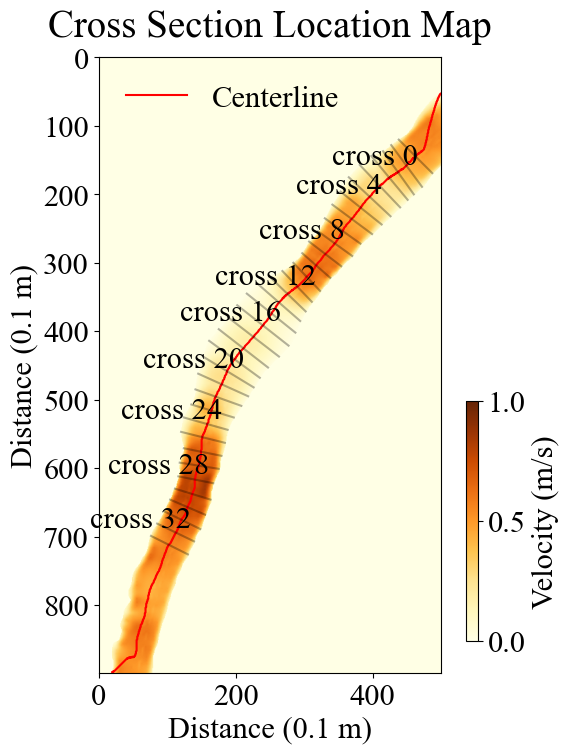

In [9]:
dem_dataV = tiff.imread(RiverData_path / 'Vx.tif')

dem_dataV = np.nan_to_num(dem_dataV, nan=0)
dem_dataV = np.where(dem_dataV < 0, 0, dem_dataV)
V1 = dem_dataV[3300:4200,1400:1900]

fig = plt.figure(figsize=(15, 8),dpi=100)
plt.rcParams['font.family'] = 'Times New Roman'
im = plt.imshow(V1, cmap='YlOrBr', vmin=0, vmax=1)  
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=22)
cbar.set_label('Velocity (m/s)', fontsize=22)
cbar.ax.set_position([0.85, 0.15, 0.02, 0.3]) 
plt.plot(centerline_points[:,0], centerline_points[:,1], 'r-', linewidth=1.5, label='Centerline')

for i, (left, right) in enumerate(boundary_points):
    plt.plot([left[0], right[0]], [left[1], right[1]], 'black', alpha=0.3)
    # Label every 5th cross-section
    if i % 4 == 0:
        mid_x = ((left[0] + right[0]) / 2)-60
        mid_y = (left[1] + right[1]) / 2
        plt.text(mid_x, mid_y, f'cross {i}', color='black', fontsize=22, 
                fontweight='normal', ha='center', va='center')

plt.title('Cross Section Location Map', fontsize=28, pad=15)
plt.legend(fontsize=22,loc='upper left',frameon=False)
plt.xlabel('Distance (0.1 m)', fontsize=22)
plt.ylabel('Distance (0.1 m)', fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)

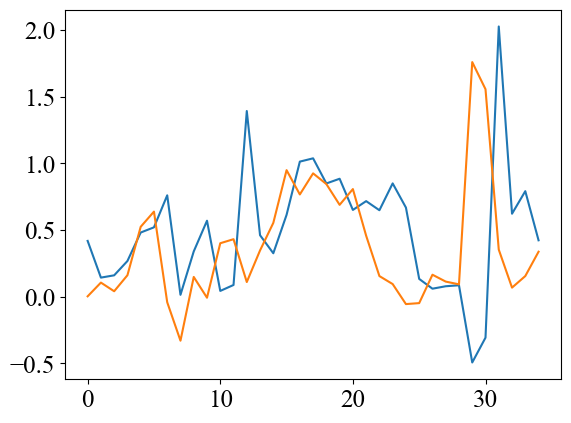

In [10]:
plt.plot(H_predl)
plt.plot(H_predr)